# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.

## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

In [36]:

import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import utils
from snntorch import spikeplot as splt

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import random

# Фиксируем seed для воспроизводимости
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


## 1. Моделирование LIF-нейрона

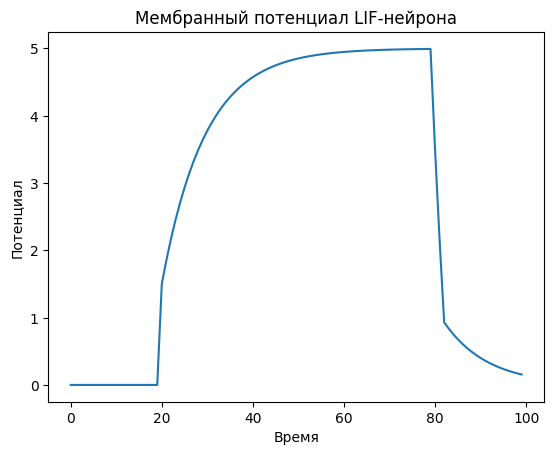

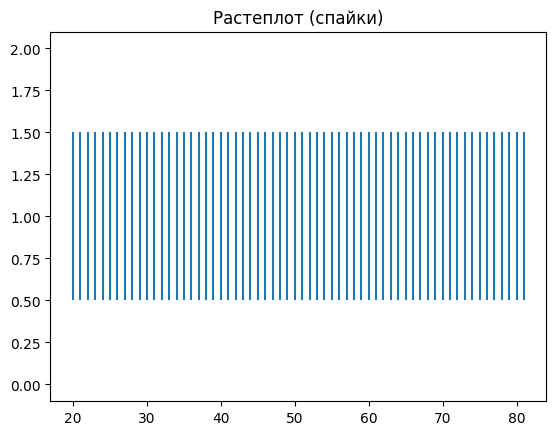

In [37]:

beta = 0.9  # коэффициент утечки
lif = snn.Leaky(beta=beta)

num_steps = 100
input_current = torch.cat((torch.zeros(20), torch.ones(60)*1.5, torch.zeros(20)))

mem = torch.zeros(1)
spk_rec = []
mem_rec = []

for step in range(num_steps):
    spk, mem = lif(input_current[step], mem)
    spk_rec.append(spk.item())
    mem_rec.append(mem.item())

plt.figure()
plt.plot(mem_rec)
plt.title("Мембранный потенциал LIF-нейрона")
plt.xlabel("Время")
plt.ylabel("Потенциал")
plt.show()

plt.figure()
plt.eventplot([i for i, s in enumerate(spk_rec) if s == 1])
plt.title("Растеплот (спайки)")
plt.show()


## 2. Подготовка данных (MNIST, уменьшенный датасет)

In [38]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

# Уменьшаем датасет для ускорения
subset_indices = list(range(10000))
train_subset = torch.utils.data.Subset(train_dataset, subset_indices)

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)


## 3. Создание SNN (двухслойная сеть LIF)

In [39]:

num_inputs = 28*28
num_hidden = 100
num_outputs = 10
num_steps = 25

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=0.9, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        spk2_rec = []
        total_spikes = 0
        
        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            
            spk2_rec.append(spk2)
            
            total_spikes += spk1.sum() + spk2.sum()
        
        return torch.stack(spk2_rec), total_spikes

net = Net()
loss_fn = SF.ce_count_loss()
optimizer = optim.Adam(net.parameters(), lr=1e-3)


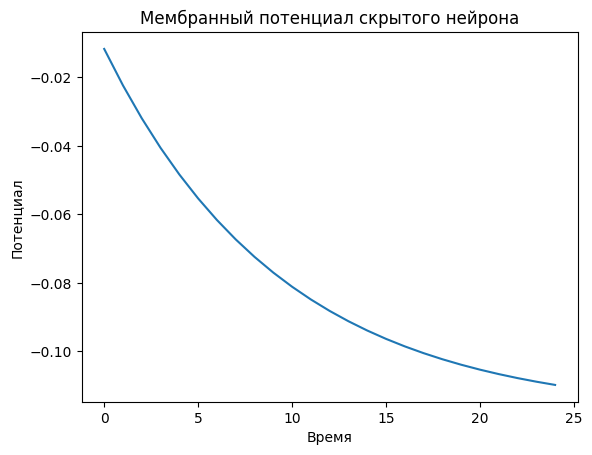

In [40]:
data_iter = iter(test_loader)
data, targets = next(data_iter)
data = data.view(data.size(0), -1)

mem1 = net.lif1.init_leaky()
mem_trace = []

with torch.no_grad():
    for step in range(num_steps):
        cur1 = net.fc1(data)
        spk1, mem1 = net.lif1(cur1, mem1)
        mem_trace.append(mem1[0][0].item())  # первый нейрон

plt.figure()
plt.plot(mem_trace)
plt.title("Мембранный потенциал скрытого нейрона")
plt.xlabel("Время")
plt.ylabel("Потенциал")
plt.show()

## 4. Обучение сети

In [41]:
epochs = 3
loss_hist = []

for epoch in range(epochs):
    for data, targets in train_loader:
        data = data.view(data.size(0), -1)
        
        spk_rec, _ = net(data)
        loss = loss_fn(spk_rec, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    loss_hist.append(loss.item())
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.2970
Epoch 2, Loss: 0.3331
Epoch 3, Loss: 0.0569


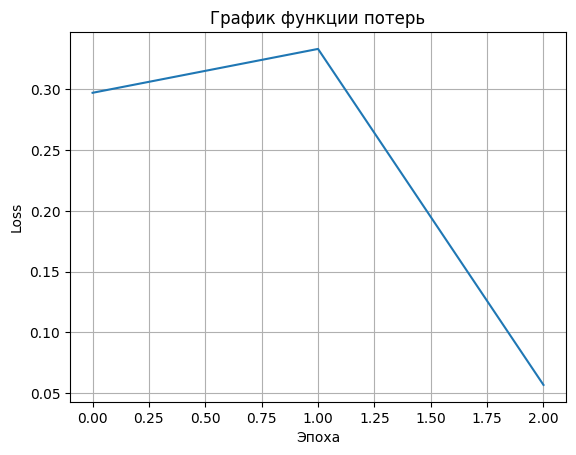

In [42]:
plt.figure()
plt.plot(loss_hist)
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid()
plt.show()

## 5. Оценка точности и энергоэффективности

Точность: 93.28%
Среднее количество спайков на образ (энергия): 345.32


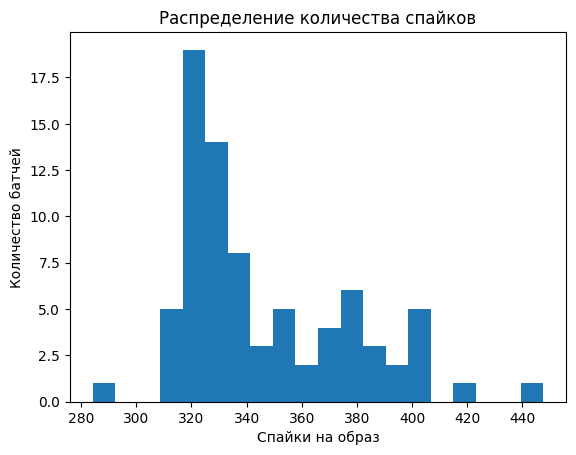

In [43]:

correct = 0
total = 0
total_spikes_all = 0

with torch.no_grad():
    for data, targets in test_loader:
        data = data.view(data.size(0), -1)
        
        spk_rec, total_spikes = net(data)
        
        _, predicted = spk_rec.sum(0).max(1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
        total_spikes_all += total_spikes.item()

accuracy = 100 * correct / total
avg_spikes_per_sample = total_spikes_all / total

print(f"Точность: {accuracy:.2f}%")
print(f"Среднее количество спайков на образ (энергия): {avg_spikes_per_sample:.2f}")

spike_distribution = []

with torch.no_grad():
    for data, targets in test_loader:
        data = data.view(data.size(0), -1)
        _, total_spikes = net(data)
        spike_distribution.append(total_spikes.item() / data.size(0))

plt.figure()
plt.hist(spike_distribution, bins=20)
plt.title("Распределение количества спайков")
plt.xlabel("Спайки на образ")
plt.ylabel("Количество батчей")
plt.show()



## 6. Анализ энергоэффективности

В данной работе «энергия» определялась как общее количество спайков, 
сгенерированных сетью при классификации одного входного образа.

Выводы:

- Энергопотребление напрямую связано с числом активных нейронов.
- Уменьшение числа временных шагов снижает расход энергии.
- Разреженная спайковая активность повышает энергоэффективность.
- SNN потенциально более энергоэффективны по сравнению с классическими ANN,
  поскольку вычисления происходят только при наличии спайков.
